# Session 14 — Growing a dense model into a mixture of experts

**Stephen Raj Arokiasamy**

The assignment: *train a dense model, convert it into a mixture-of-experts model, and show that the
converted model keeps training and keeps reducing its loss.*

The plan, in two phases on one fixed stream of 50M tokens:

```
phase 1   dense GPT, 20.9M parameters, tokens 0 -> 25M                    (one run)
          ─────────────────────────── checkpoint at 25M ───────────────────────────
phase 2   tokens 25M -> 50M, three branches from the SAME checkpoint, SAME batches:
            A  dense, trained on                      the control
            B  drop-upcycled MoE, bias balancing      8 experts, top-2, r = 0.5
            C  drop-upcycled MoE, auxiliary loss      same, Switch-style balancing
```

"Keeps training and reduces loss" is easy to show and proves little on its own: any model with a
decaying learning rate keeps reducing its loss. So the question the notebook actually answers is
narrower. **After conversion, does the MoE learn faster than the dense model it came from, when both
see exactly the same tokens?** Branch A is there to answer that.

| | |
|---|---|
| dense model | GPT, `d=256`, 10 layers, 4 heads, context 512, GPT-2 vocabulary, tied embeddings — 20.88M parameters |
| MoE model | the same, with every feed-forward block replaced by 8 experts of the same shape, top-2 routing — 57.6M total, 26.1M active |
| conversion | **drop-upcycling** (Nakamura et al., ICLR 2025): each expert is a copy of the dense FFN with a random half of its 1,024 hidden neurons redrawn |
| data | FineWeb-Edu `sample-10BT`, GPT-2 BPE, one pass over 50M tokens, the same token order for every run |
| hardware | free Colab T4, fp16 with a loss scaler; the router always runs in fp32 |

**Running it.** Runtime → T4 GPU → Run all. Total is about 100M tokens of training (25M dense, then
three 25M branches), roughly 50 minutes. Every run checkpoints every five minutes and a re-run resumes
where it stopped; results go to Google Drive when it mounts, `/content` otherwise.

In [1]:
import os, sys, math, time, json, gc, hashlib, subprocess
OFFLINE = os.environ.get("S14_OFFLINE") == "1"          # used by verify_local.py only
if not OFFLINE:
    try:
        import tiktoken, datasets                          # noqa: F401
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", "tiktoken", "datasets"], check=True)
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

SEED = 14
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
if DEVICE == "cuda":
    CAP = torch.cuda.get_device_capability()
    AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16   # T4 (7.5): fp16 + loss scaling
    GPU_GIB = torch.cuda.get_device_properties(0).total_memory / 2**30
else:
    CAP, AMP_DTYPE, GPU_GIB = None, torch.float32, None
USE_AMP = AMP_DTYPE != torch.float32
USE_SCALER = AMP_DTYPE == torch.float16

def envi(k, d): return int(os.environ.get(k, d))

if OFFLINE:   # a miniature of the real configuration, so every cell runs on a laptop CPU
    CFG = dict(vocab=512, d=64, layers=4, heads=2, seq=64, batch=8,
               dense_tokens=envi("S14_DENSE", 40_960), grow_tokens=envi("S14_GROW", 40_960),
               val_tokens=16_384, eval_seqs=32, final_eval_seqs=64, lr=3e-3,
               experts=4, topk=2, drop=0.5, gamma=1e-3, alpha=1e-2, rewarm=10)
else:
    CFG = dict(vocab=50304, d=256, layers=10, heads=4, seq=512, batch=32,
               dense_tokens=envi("S14_DENSE", 25_000_000), grow_tokens=envi("S14_GROW", 25_000_000),
               val_tokens=1_048_576, eval_seqs=128, final_eval_seqs=512, lr=1e-3,
               experts=8, topk=2, drop=0.5, gamma=1e-3, alpha=1e-2, rewarm=100)
CFG["train_tokens"] = CFG["dense_tokens"] + CFG["grow_tokens"]
T = CFG["seq"]

# Colab wipes /content on disconnect, so data, results and checkpoints go to Drive when it mounts.
RUN_DIR = os.environ.get("S14_RUN_DIR")
if RUN_DIR is None:
    RUN_DIR = "s14_runs"
    if os.path.isdir("/content"):
        RUN_DIR = "/content/s14_runs"
        if not OFFLINE and os.environ.get("S14_NO_DRIVE") != "1":
            try:
                from google.colab import drive
                drive.mount("/content/drive")
                RUN_DIR = "/content/drive/MyDrive/s14_runs"
            except Exception as e:
                print("Drive not mounted, results stay in /content and will NOT survive a disconnect:", e)
os.makedirs(RUN_DIR, exist_ok=True)
CKPT_SECONDS = envi("S14_CKPT_SECONDS", 300)
FORCE = os.environ.get("S14_FORCE") == "1"

print("torch     ", torch.__version__)
print("device    ", DEVICE, "|", GPU, f"| {GPU_GIB:.1f} GiB" if GPU_GIB else "")
print("precision ", AMP_DTYPE, "| loss scaler" if USE_SCALER else "", "| router always fp32")
print("config    ", CFG)
print("results   ", RUN_DIR, f"| checkpoint every {CKPT_SECONDS}s, Run all resumes")

Drive not mounted, results stay in /content and will NOT survive a disconnect: Error: credential propagation was unsuccessful
torch      2.11.0+cu128
device     cuda | Tesla T4 | 14.6 GiB
precision  torch.float16 | loss scaler | router always fp32
config     {'vocab': 50304, 'd': 256, 'layers': 10, 'heads': 4, 'seq': 512, 'batch': 32, 'dense_tokens': 25000000, 'grow_tokens': 25000000, 'val_tokens': 1048576, 'eval_seqs': 128, 'final_eval_seqs': 512, 'lr': 0.001, 'experts': 8, 'topk': 2, 'drop': 0.5, 'gamma': 0.001, 'alpha': 0.01, 'rewarm': 100, 'train_tokens': 50000000}
results    /content/s14_runs | checkpoint every 300s, Run all resumes


## 1 · Data: one fixed stream of 50M tokens

The same FineWeb-Edu pipeline as Session 13: streamed, tokenized with GPT-2 BPE, written once. The
first 1M tokens are validation. Training reads windows of 512 in one fixed random order. Phase 1 takes
the first 25M tokens of that order; phase 2 takes the **next** 25M, so the whole experiment is one
epoch, no token is seen twice, and the three phase-2 branches see identical batches in identical order.

In [2]:
DATA_DIR = os.path.join(RUN_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)
n_chunks_needed = math.ceil(CFG["train_tokens"] / T)
N_TRAIN = n_chunks_needed * T + 1                         # +1 so the last window has a target
N_VAL = CFG["val_tokens"]

def build_fineweb(path, need):
    import tiktoken
    from datasets import load_dataset
    enc = tiktoken.get_encoding("gpt2"); eot = enc.eot_token
    ds = load_dataset("HuggingFaceFW/fineweb-edu", name="sample-10BT", split="train", streaming=True)
    buf = np.empty(need, dtype=np.uint16); pos = docs = 0; pending = []
    t0 = time.time()
    for ex in ds:
        pending.append(ex["text"])
        if len(pending) < 512:
            continue
        for ids in enc.encode_ordinary_batch(pending, num_threads=8):
            ids.append(eot)
            n = min(len(ids), need - pos)
            buf[pos:pos + n] = ids[:n]; pos += n; docs += 1
            if pos >= need: break
        pending = []
        if pos >= need: break
        if docs % 20480 < 512:
            print(f"  {pos/1e6:6.1f}M tokens from {docs:,} documents  ({time.time()-t0:.0f}s)")
    assert pos == need, f"stream ended early at {pos} tokens"
    buf.tofile(path + ".tmp"); os.replace(path + ".tmp", path)   # no half-written file after a crash
    return docs

def build_synthetic(path, need, vocab):
    # offline stand-in: a sparse random bigram language, so the loss has something to learn
    rng = np.random.default_rng(SEED)
    succ = rng.integers(0, vocab, size=(vocab, 8))
    toks = np.empty(need, dtype=np.uint16); toks[0] = 0
    choice = rng.integers(0, 8, size=need)
    for i in range(1, need):
        toks[i] = succ[toks[i-1], choice[i]]
    toks.tofile(path)
    return 0

name = "synthetic" if OFFLINE else "fineweb_edu_gpt2"
bin_path = os.path.join(DATA_DIR, f"{name}_{N_VAL + N_TRAIN}.bin")
man_path = bin_path + ".json"
if not os.path.exists(man_path):
    t0 = time.time()
    docs = (build_synthetic(bin_path, N_VAL + N_TRAIN, CFG["vocab"]) if OFFLINE
            else build_fineweb(bin_path, N_VAL + N_TRAIN))
    sha = hashlib.sha256(open(bin_path, "rb").read()).hexdigest()
    json.dump(dict(source=name, tokens=N_VAL + N_TRAIN, documents=docs, sha256=sha,
                   seconds=round(time.time() - t0, 1)), open(man_path, "w"), indent=1)
MANIFEST = json.load(open(man_path))
ALL = np.fromfile(bin_path, dtype=np.uint16)
assert len(ALL) == MANIFEST["tokens"]
VAL, TRAIN = ALL[:N_VAL], ALL[N_VAL:]

N_CHUNKS = (len(TRAIN) - 1) // T
PERM = np.random.default_rng(SEED).permutation(N_CHUNKS)   # one epoch, one fixed order for all runs

def chunk_batch(ids, src=None):
    src = TRAIN if src is None else src
    x = np.stack([src[i*T:i*T + T + 1] for i in ids]).astype(np.int64)
    x = torch.from_numpy(x)
    if DEVICE == "cuda": x = x.pin_memory().to(DEVICE, non_blocking=True)
    return x[:, :-1], x[:, 1:]

VAL_CHUNKS = (len(VAL) - 1) // T
print(f"source      {MANIFEST['source']}  ({MANIFEST['documents']:,} documents)")
print(f"sha256      {MANIFEST['sha256'][:16]}...")
print(f"validation  {len(VAL):,} tokens -> {VAL_CHUNKS:,} windows of {T}")
print(f"training    {N_CHUNKS:,} windows of {T} = {N_CHUNKS*T:,} tokens, one epoch, fixed order")
STEPS_TOTAL = N_CHUNKS // CFG["batch"]
STEPS_DENSE = math.ceil(CFG["dense_tokens"] / T) // CFG["batch"]
print(f"schedule    {STEPS_TOTAL:,} steps of {CFG['batch']} x {T}; phase 1 = steps 0-{STEPS_DENSE-1:,},"
      f" phase 2 = steps {STEPS_DENSE:,}-{STEPS_TOTAL-1:,}")

README.md:   0%|          | 0.00/26.4k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

    21.3M tokens from 20,480 documents  (26s)
    42.8M tokens from 40,960 documents  (51s)
source      fineweb_edu_gpt2  (48,508 documents)
sha256      1a6babadb992208e...
validation  1,048,576 tokens -> 2,047 windows of 512
training    97,657 windows of 512 = 50,000,384 tokens, one epoch, fixed order
schedule    3,051 steps of 32 x 512; phase 1 = steps 0-1,524, phase 2 = steps 1,525-3,050


## 2 · The dense model and the MoE layer

The dense block is a standard pre-LayerNorm GPT block, and its feed-forward network (FFN) is
`fc: 256 → 1,024`, GELU, `fc2: 1,024 → 256`. The MoE block keeps attention exactly as it is and
replaces that FFN with a router and 8 experts, each an FFN of **the same shape**:

$$y = \sum_{i \in \text{top-2}} g_i \, E_i(x), \qquad g = \text{renormalise}\big(\text{softmax}(W_r x)_{\text{top-2}}\big)$$

Three details from the lesson, all implemented:

* **The router runs in fp32** whatever the training precision (§7: Switch diverged in 16-bit), and it
  starts at one tenth of the usual initialisation scale.
* **No token is dropped.** Every expert processes every token routed to it (§11: dropless is better).
* **Balancing** is one of two methods, chosen per run (§12, §13):
  * `bias` — a per-expert bias added to the score **only when choosing** the top-2. The weights `g`
    come from the unbiased scores, so the bias never touches the language-model gradient. After each
    step, every bias moves by `γ · sign(mean load − load)`, with γ = 0.001.
  * `aux` — Switch's auxiliary loss `α · N · Σ fᵢ Pᵢ`, α = 0.01, added to the training loss.

The load is counted over the whole batch of 32 sequences, which on one GPU is the global batch (§14).

In [3]:
class Attn(nn.Module):
    def __init__(s, d, h):
        super().__init__()
        s.h = h
        s.qkv = nn.Linear(d, 3 * d, bias=False)
        s.proj = nn.Linear(d, d, bias=False)
    def forward(s, x):
        B, L, D = x.shape
        q, k, v = s.qkv(x).view(B, L, 3, s.h, D // s.h).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return s.proj(y.transpose(1, 2).reshape(B, L, D))

class FFN(nn.Module):                                   # the dense FFN, and the shape of one expert
    def __init__(s, d, hidden):
        super().__init__()
        s.fc, s.fc2 = nn.Linear(d, hidden, bias=False), nn.Linear(hidden, d, bias=False)
    def forward(s, x):
        return s.fc2(F.gelu(s.fc(x)))

def switch_aux(counts, probs, k):
    # Switch Transformer: N * sum_i f_i * P_i. f_i = share of dispatched copies (no gradient),
    # P_i = mean router probability (has a gradient). Equals 1 when perfectly even.
    E = probs.shape[-1]
    f = counts.float() / counts.sum()
    return E * (f * probs.mean(0)).sum()

class MoE(nn.Module):
    def __init__(s, d, hidden, E, k, balance):
        super().__init__()
        s.E, s.k, s.balance = E, k, balance
        s.router = nn.Linear(d, E, bias=False)
        s.experts = nn.ModuleList(FFN(d, hidden) for _ in range(E))
        s.register_buffer("bias", torch.zeros(E))      # used for choosing only; saved in checkpoints
        s.counts = torch.zeros(E); s.aux = torch.zeros(())
    def route(s, xf):
        # fp32 router, whatever autocast says
        with torch.autocast(xf.device.type, enabled=False):
            logits = xf.float() @ s.router.weight.float().t()
            probs = logits.softmax(-1)
        choose = probs + s.bias if s.balance == "bias" else probs
        top = choose.topk(s.k, dim=-1).indices
        w = probs.gather(1, top)
        return probs, top, w / w.sum(-1, keepdim=True)
    def forward(s, x):
        B_, L_, D = x.shape
        xf = x.reshape(-1, D)
        probs, top, w = s.route(xf)
        out = torch.zeros(xf.shape, dtype=torch.float32, device=x.device)
        for e in range(s.E):
            rows, slot = (top == e).nonzero(as_tuple=True)
            if rows.numel():
                y = s.experts[e](xf[rows])
                out.index_add_(0, rows, y.float() * w[rows, slot, None])
        s.counts = torch.bincount(top.flatten(), minlength=s.E).detach()
        s.aux = switch_aux(s.counts, probs, s.k)
        return out.view(B_, L_, D).to(x.dtype)

class Block(nn.Module):
    def __init__(s, d, h, moe=None):
        super().__init__()
        s.ln1, s.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        s.attn = Attn(d, h)
        s.ffn = FFN(d, 4 * d) if moe is None else MoE(d, 4 * d, **moe)
    def forward(s, p):
        p = p + s.attn(s.ln1(p))
        return p + s.ffn(s.ln2(p))

class FusedLinearCE(torch.autograd.Function):
    # loss = mean CE(h @ W^T, t), computed 2,048 tokens at a time; both gradients are formed in
    # the forward pass, so the (tokens x vocab) logit table never exists in full
    @staticmethod
    def forward(ctx, h, W, t, need_grad, chunk=2048):
        # follow the caller: inside autocast use its dtype, outside it stay in fp32. (An earlier
        # build always used the AMP dtype on CUDA, so its "fp32" check was really a 16-bit one.)
        cd = AMP_DTYPE if (h.is_cuda and torch.is_autocast_enabled()) else torch.float32
        Wc = W.to(cd)
        N = h.shape[0]
        loss = torch.zeros((), dtype=torch.float32, device=h.device)
        gh = torch.empty(h.shape, dtype=torch.float32, device=h.device) if need_grad else None
        gW = torch.zeros(W.shape, dtype=torch.float32, device=h.device) if need_grad else None
        for i in range(0, N, chunk):
            hc, tc = h[i:i + chunk].to(cd), t[i:i + chunk]
            logits = (hc @ Wc.t()).float()
            lse = torch.logsumexp(logits, dim=-1)
            loss += (lse - logits.gather(1, tc[:, None]).squeeze(1)).sum()
            if need_grad:
                # (softmax - onehot) lies in [-1, 1], which fp16 holds well. Dividing by N first
                # would push most entries below fp16's normal range (6e-5) at 16k tokens per step;
                # standard AMP avoids that because the loss scale is applied before the cast. So
                # the 1/N is applied after the matmul, in fp32.
                probs = torch.exp(logits - lse[:, None])
                probs[torch.arange(len(tc), device=h.device), tc] -= 1.0
                probs = probs.to(cd)
                gh[i:i + chunk] = (probs @ Wc).float() / N
                gW += (probs.t() @ hc).float() / N
        if need_grad:
            ctx.save_for_backward(gh, gW)
        ctx.dt = (h.dtype, W.dtype)
        return loss / N

    @staticmethod
    def backward(ctx, go):
        gh, gW = ctx.saved_tensors
        return (gh * go).to(ctx.dt[0]), (gW * go).to(ctx.dt[1]), None, None, None

def fused_ce(h, W, t):
    need = torch.is_grad_enabled() and (h.requires_grad or W.requires_grad)
    return FusedLinearCE.apply(h, W, t, need)

class LM(nn.Module):
    def __init__(s, moe=None):
        super().__init__()
        V, D = CFG["vocab"], CFG["d"]
        s.emb = nn.Embedding(V, D)
        s.pos = nn.Parameter(torch.zeros(1, T, D))
        s.blocks = nn.ModuleList(Block(D, CFG["heads"], moe) for _ in range(CFG["layers"]))
        s.ln_f = nn.LayerNorm(D)
        s.apply(s._init)
        for n, p in s.named_parameters():
            if n.endswith("proj.weight") or n.endswith("fc2.weight"):
                nn.init.normal_(p, 0.0, 0.02 / math.sqrt(2 * CFG["layers"]))
            if n.endswith("router.weight"):
                nn.init.normal_(p, 0.0, 0.002)          # a tenth of the usual scale (Switch)
    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, 0.0, 0.02)
    @property
    def moes(s):
        return [b.ffn for b in s.blocks if isinstance(b.ffn, MoE)]
    def forward(s, idx, targets):
        p = s.emb(idx) + s.pos[:, :idx.shape[1]]
        for b in s.blocks:
            p = b(p)
        h = s.ln_f(p).reshape(-1, CFG["d"])
        return fused_ce(h, s.emb.weight, targets.reshape(-1))

def moe_cfg(balance):
    return dict(E=CFG["experts"], k=CFG["topk"], balance=balance)

def count(m):
    return sum(p.numel() for p in m.parameters())

dense = LM(); moe = LM(moe_cfg("bias"))
N_DENSE, N_MOE = count(dense), count(moe)
FFN_P = count(dense.blocks[0].ffn)
N_ACTIVE = N_DENSE + CFG["layers"] * ((CFG["topk"] - 1) * FFN_P + CFG["d"] * CFG["experts"])
ATTN_FLOP = 12 * CFG["layers"] * CFG["d"] * T
FLOP_DENSE, FLOP_MOE = 6 * N_DENSE + ATTN_FLOP, 6 * N_ACTIVE + ATTN_FLOP
print(f"dense model      {N_DENSE:,} parameters")
print(f"one FFN / expert {FFN_P:,} parameters  ({CFG['d']} -> {4*CFG['d']} -> {CFG['d']})")
print(f"MoE model        {N_MOE:,} total  ({N_MOE/N_DENSE:.2f}x the dense model)")
print(f"                 {N_ACTIVE:,} active per token  ({CFG['topk']} of {CFG['experts']} experts + router)")
print(f"training FLOPs per token: dense {FLOP_DENSE/1e6:.1f}M, MoE {FLOP_MOE/1e6:.1f}M"
      f"  (+{100*(FLOP_MOE/FLOP_DENSE-1):.0f}%)")
del dense, moe

dense model      20,883,968 parameters
one FFN / expert 524,288 parameters  (256 -> 1024 -> 256)
MoE model        57,604,608 total  (2.76x the dense model)
                 26,147,328 active per token  (2 of 8 experts + router)
training FLOPs per token: dense 141.0M, MoE 172.6M  (+22%)


## 3 · Drop-upcycling: turning one FFN into 8 experts

Copying the dense FFN into every expert (sparse upcycling) preserves the model exactly, and that is
also its weakness: 8 identical experts give the router nothing to tell apart, and the lesson's
Lightning LM account shows identical clones collapsing onto a few members. Drop-upcycling breaks the
symmetry on purpose. For each expert, a different random half of the 1,024 hidden neurons is
**redrawn**: that neuron's row of `fc` and column of `fc2` are replaced by Gaussian noise with the mean
and standard deviation of the weights being replaced (Nakamura et al., 2025). The other half is kept
from the dense model.

Everything that is not an FFN — embeddings, attention, LayerNorms — is copied unchanged. The router is
new, initialised small, so at step 0 it routes almost uniformly.

So the converted model does **not** start exactly where the dense model stopped: half of every
expert's knowledge has been deliberately erased. How large that jump is, and how fast it is recovered,
is the first thing phase 2 measures.

In [4]:
def upcycle(dense_state, balance, r=None, seed=SEED):
    # returns an MoE model built from a dense state dict, and the redrawn-neuron masks
    r = CFG["drop"] if r is None else r
    torch.manual_seed(seed)
    m = LM(moe_cfg(balance))
    own = m.state_dict()
    for k_, v in dense_state.items():
        if ".ffn." not in k_:
            own[k_] = v.clone()                        # embeddings, attention, norms: unchanged
    g = torch.Generator().manual_seed(seed)
    H = 4 * CFG["d"]; n_drop = int(round(r * H))
    masks = {}
    for li in range(CFG["layers"]):
        W1 = dense_state[f"blocks.{li}.ffn.fc.weight"].float().cpu()      # (H, d)
        W2 = dense_state[f"blocks.{li}.ffn.fc2.weight"].float().cpu()     # (d, H)
        for e in range(CFG["experts"]):
            idx = torch.randperm(H, generator=g)[:n_drop]
            w1, w2 = W1.clone(), W2.clone()
            if n_drop:
                o1, o2 = W1[idx, :], W2[:, idx]
                w1[idx, :] = torch.randn(o1.shape, generator=g) * o1.std() + o1.mean()
                w2[:, idx] = torch.randn(o2.shape, generator=g) * o2.std() + o2.mean()
            own[f"blocks.{li}.ffn.experts.{e}.fc.weight"] = w1
            own[f"blocks.{li}.ffn.experts.{e}.fc2.weight"] = w2
            masks[(li, e)] = idx
    m.load_state_dict(own)
    return m, masks

## 4 · Before training: is the conversion right?

Four checks, all on freshly built models.

**(a) With nothing redrawn, conversion is exact.** If `r = 0`, every expert is the dense FFN, and the
top-2 weights add up to one, so the MoE computes `g₁·FFN(x) + g₂·FFN(x) = FFN(x)`. The upcycled model's
loss must equal the dense model's. This is the check that the MoE layer, the routing and the weight
copying are all wired correctly; drop-upcycling then departs from it on purpose.

**(b) Drop-upcycling redraws exactly what it should.** Each expert has exactly `r · 1,024` neurons
redrawn, keeps the rest bit-for-bit, and two experts' redrawn sets overlap about `r²` of the time, as
two independent random halves should.

**(c) The balancing bias changes which experts are chosen, never how they are weighted.**

**(d) The auxiliary loss has the right values at the two extremes.** Perfectly even load gives 1.
Collapse onto one expert gives `N` with top-1 — the lesson's `α · N` — but only `N/2` with top-2,
because each token's two picks must be different experts, so no expert can take more than half the
dispatched copies.

In [5]:
torch.manual_seed(0)
dense0 = LM().to(DEVICE)
with torch.no_grad():                                     # give the FFNs some size, as training would
    for b in dense0.blocks:
        b.ffn.fc2.weight.mul_(8.0)
x, y = chunk_batch(range(4))
exact, _ = upcycle({k: v.detach().cpu() for k, v in dense0.state_dict().items()}, "bias", r=0.0)
exact = exact.to(DEVICE)
with torch.no_grad():
    l_dense, l_exact = dense0(x, y).item(), exact(x, y).item()
    h = torch.randn(64, CFG["d"], device=DEVICE)
    ffn_gap = (exact.blocks[0].ffn(h[None]) [0] - dense0.blocks[0].ffn(h)).abs().max().item()
CHECK = dict(exact_loss_gap=abs(l_dense - l_exact), exact_ffn_gap=ffn_gap)
print("(a) upcycling with r = 0 reproduces the dense model")
print(f"    dense loss {l_dense:.6f}   upcycled loss {l_exact:.6f}   |gap| {CHECK['exact_loss_gap']:.1e}")
print(f"    one layer, max |MoE(x) - FFN(x)| on random input: {ffn_gap:.1e}")

up, masks = upcycle({k: v.detach().cpu() for k, v in dense0.state_dict().items()}, "bias")
H = 4 * CFG["d"]; n_drop = int(round(CFG["drop"] * H))
sizes = {len(v) for v in masks.values()}
W1 = dense0.blocks[0].ffn.fc.weight.detach().cpu()
kept_ok = all(torch.equal(up.blocks[0].ffn.experts[e].fc.weight.detach()[
                  torch.tensor(sorted(set(range(H)) - set(masks[(0, e)].tolist())))],
                  W1[torch.tensor(sorted(set(range(H)) - set(masks[(0, e)].tolist())))])
              for e in range(CFG["experts"]))
ov = [len(set(masks[(0, i)].tolist()) & set(masks[(0, j)].tolist())) / H
      for i in range(CFG["experts"]) for j in range(i + 1, CFG["experts"])]
CHECK.update(drop_sizes=sorted(sizes), kept_exact=kept_ok, overlap=float(np.mean(ov)))
print(f"\n(b) drop-upcycling, r = {CFG['drop']}: redrawn neurons per expert {sorted(sizes)} of {H}"
      f" | kept neurons bit-identical: {kept_ok}")
print(f"    mean overlap of two experts' redrawn sets: {CHECK['overlap']:.3f} of the layer"
      f" (independent random halves: r^2 = {CFG['drop']**2:.3f})")

m0 = up.blocks[0].ffn.to(DEVICE)
xf = torch.randn(256, CFG["d"], device=DEVICE)
with torch.no_grad():
    probs, top0, w0 = m0.route(xf)
    m0.bias[0] = 10.0                                     # force expert 0 into every choice
    probs1, top1, w1 = m0.route(xf)
    m0.bias.zero_()
chosen0 = (top1 == 0).any(-1).float().mean().item()
w_ref = probs1.gather(1, top1); w_ref = w_ref / w_ref.sum(-1, keepdim=True)
CHECK.update(bias_forces=chosen0, bias_weights_gap=(w1 - w_ref).abs().max().item(),
             probs_unchanged=(probs1 - probs).abs().max().item())
print(f"\n(c) bias +10 on expert 0: chosen for {100*chosen0:.0f}% of tokens;"
      f" router probabilities changed by {CHECK['probs_unchanged']:.1e};"
      f" weights = renormalised unbiased probabilities to {CHECK['bias_weights_gap']:.1e}")

E_ = CFG["experts"]; P_even = torch.full((10, E_), 1.0 / E_)
even = switch_aux(torch.full((E_,), 5), P_even, 2).item()
P_one = torch.zeros(10, E_); P_one[:, 0] = 1.0
c1 = torch.zeros(E_); c1[0] = 10
c2 = torch.zeros(E_); c2[0] = 10; c2[1] = 10
col1, col2 = switch_aux(c1, P_one, 1).item(), switch_aux(c2, P_one, 2).item()
CHECK.update(aux_even=even, aux_collapse_k1=col1, aux_collapse_k2=col2)
print(f"\n(d) Switch auxiliary term (before alpha): even {even:.3f} | collapsed, top-1 {col1:.3f}"
      f" (= N = {E_}) | collapsed, top-2 {col2:.3f} (= N/2)")
print(f"    with alpha = {CFG['alpha']}: {CFG['alpha']*even:.3f} when even, up to {CFG['alpha']*col1:.2f}")
del dense0, exact, up, m0

(a) upcycling with r = 0 reproduces the dense model
    dense loss 10.859109   upcycled loss 10.859109   |gap| 0.0e+00
    one layer, max |MoE(x) - FFN(x)| on random input: 3.6e-07

(b) drop-upcycling, r = 0.5: redrawn neurons per expert [512] of 1024 | kept neurons bit-identical: True
    mean overlap of two experts' redrawn sets: 0.249 of the layer (independent random halves: r^2 = 0.250)

(c) bias +10 on expert 0: chosen for 100% of tokens; router probabilities changed by 0.0e+00; weights = renormalised unbiased probabilities to 0.0e+00

(d) Switch auxiliary term (before alpha): even 1.000 | collapsed, top-1 8.000 (= N = 8) | collapsed, top-2 4.000 (= N/2)
    with alpha = 0.01: 0.010 when even, up to 0.08


## 5 · One training loop for every run

Every run uses the same loop. It has:

* AdamW, with β = (0.9, 0.95) and weight decay 0.1 on the matrices;
* gradient clipping at 1.0;
* fp16 autocast with a dynamic loss scaler;
* a fused cross-entropy head.

**One learning-rate schedule spans the whole experiment.** It is a 3% warmup, then a cosine decay to
10% over all 3,051 steps. Phase 1 is its first half. Each phase-2 branch picks it up at step 1,525
from a **fresh optimizer**, which fits the MoE, whose experts are new tensors with no Adam history.
Each branch warms back up to the scheduled rate over 100 steps. The dense branch is treated
identically, so the conversion is the only difference between them.

After each step, the `bias` runs move every expert's bias by γ · sign(mean load − load). The `aux`
runs add α times the mean auxiliary term over the 10 layers to the loss. Checkpoints hold model,
optimizer, scaler and curves every five minutes. The biases are registered buffers, so they are
checkpointed with the model.

In [6]:
def make_opt(model, lr):
    decay = [p for p in model.parameters() if p.dim() >= 2]
    rest = [p for p in model.parameters() if p.dim() < 2]
    kw = dict(fused=True) if DEVICE == "cuda" else {}
    return torch.optim.AdamW([dict(params=decay, weight_decay=0.1), dict(params=rest, weight_decay=0.0)],
                             lr=lr, betas=(0.9, 0.95), eps=1e-8, **kw)

WARM = max(1, int(0.03 * STEPS_TOTAL))
def lr_at(s, lr):
    if s < WARM: return lr * (s + 1) / WARM
    q = (s - WARM) / max(1, STEPS_TOTAL - WARM)
    return lr * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * q)))

def load_stats(counts):
    # counts: (layers, E). MaxVio per layer, averaged; dead = experts with no tokens at all
    c = counts.float()
    mean = c.mean(1, keepdim=True)
    maxvio = ((c.max(1).values - mean[:, 0]) / mean[:, 0]).mean().item()
    return maxvio, int((c == 0).sum().item())

def expert_similarity(model):
    # mean pairwise cosine similarity of the experts' fc weights, averaged over layers
    sims = []
    for m in model.moes:
        W = torch.stack([e.fc.weight.detach().float().flatten() for e in m.experts])
        W = F.normalize(W, dim=1); S = W @ W.t()
        n = len(W); sims.append(((S.sum() - n) / (n * (n - 1))).item())
    return float(np.mean(sims)) if sims else float("nan")

@torch.no_grad()
def evaluate(model, n_seqs, bs=32):
    model.eval(); tot = n = 0
    counts = torch.zeros(len(model.moes), CFG["experts"]) if model.moes else None
    for i in range(0, min(n_seqs, VAL_CHUNKS), bs):
        ids = range(i, min(i + bs, n_seqs, VAL_CHUNKS))
        x, y = chunk_batch(ids, VAL)
        with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            tot += model(x, y).item() * len(ids); n += len(ids)
        if counts is not None:
            counts += torch.stack([m.counts.float().cpu() for m in model.moes])
    model.train()
    return tot / n, counts

class Interrupted(Exception):
    pass                                                   # used by verify_local.py to simulate a disconnect

def save_atomic(obj, path):
    torch.save(obj, path + ".tmp"); os.replace(path + ".tmp", path)

def train_phase(name, build, s0, s1, lr, rewarm=0, keep_model=True, ckpt_every_steps=None,
                _interrupt_at=None):
    # trains steps s0..s1-1 of the global schedule; build() returns a fresh model (weights included)
    path = os.path.join(RUN_DIR, f"{name}.json"); ck_path = os.path.join(RUN_DIR, f"{name}.ckpt.pt")
    if os.path.exists(path) and not FORCE:
        r = json.load(open(path)); print(f"[{name}] loaded from {path}"); return r
    model = build().to(DEVICE)
    opt = make_opt(model, lr)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    balance = model.moes[0].balance if model.moes else None
    steps = s1 - s0
    log_every = max(1, steps // 200)
    evals_at = set(s0 + int(round(steps * j / 20)) for j in range(1, 20))
    skip = max(5, int(0.05 * steps))
    meta = dict(s0=s0, s1=s1, lr=lr, rewarm=rewarm, balance=balance)
    st = dict(step=s0, curve=[], vcurve=[], load=[], skipped=0, t_train=0.0, t_steady=0.0,
              tok_steady=0, diverged=False, peak=0, resumes=0)
    if os.path.exists(ck_path) and not FORCE:
        ck = torch.load(ck_path, map_location=DEVICE, weights_only=False)
        if ck["meta"] == meta:
            model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
            if USE_SCALER: scaler.load_state_dict(ck["scaler"])
            st = ck["state"]; st["resumes"] += 1
            print(f"[{name}] resuming at step {st['step']} of {s0}-{s1} from {ck_path}")
        del ck
    if st["step"] == s0:                                   # the model as it enters this phase
        v0, c0 = evaluate(model, CFG["eval_seqs"])
        st["vcurve"].append((s0 * CFG["batch"] * T, v0) + (load_stats(c0) if c0 is not None else ()))
        st["start_val"] = v0
        st["start_sim"] = expert_similarity(model)
    def checkpoint():
        if DEVICE == "cuda": st["peak"] = max(st["peak"], torch.cuda.max_memory_allocated())
        save_atomic(dict(meta=meta, model=model.state_dict(), opt=opt.state_dict(),
                         scaler=scaler.state_dict() if USE_SCALER else None, state=st), ck_path)
    run_loss = torch.zeros((), device=DEVICE); run_n = 0
    if DEVICE == "cuda": torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    t_mark = t_ck = time.perf_counter(); first = st["step"] > s0
    B = CFG["batch"]
    for s in range(st["step"], s1):
        ramp = min(1.0, (s - s0 + 1) / rewarm) if rewarm else 1.0
        for gp in opt.param_groups: gp["lr"] = lr_at(s, lr) * ramp
        x, y = chunk_batch(PERM[s * B:(s + 1) * B])
        sc0 = scaler.get_scale() if USE_SCALER else 1.0
        with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            lm_loss = model(x, y)
            loss = lm_loss
            if balance == "aux":
                loss = lm_loss + CFG["alpha"] * torch.stack([m.aux for m in model.moes]).mean()
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
        if balance == "bias":
            with torch.no_grad():
                for m in model.moes:
                    c = m.counts.float()
                    m.bias += CFG["gamma"] * torch.sign(c.mean() - c)
        if USE_SCALER and scaler.get_scale() < sc0: st["skipped"] += 1
        run_loss += lm_loss.detach(); run_n += 1
        if (s + 1) % log_every == 0 or s + 1 == s1 or (s + 1) in evals_at:
            if DEVICE == "cuda": torch.cuda.synchronize()
            now = time.perf_counter(); dt = now - t_mark; st["t_train"] += dt
            if s - s0 >= skip and not first:
                st["t_steady"] += dt; st["tok_steady"] += run_n * B * T
            first = False
            L = (run_loss / run_n).item(); run_loss.zero_(); run_n = 0
            st["curve"].append(((s + 1) * B * T, L, float(gn)))
            if model.moes:
                st["load"].append(((s + 1) * B * T,) + load_stats(torch.stack([m.counts for m in model.moes])))
            if not math.isfinite(L):
                st["diverged"] = True; st["step"] = s + 1
                print(f"[{name}] non-finite loss at step {s+1}; stopping"); break
            if (s + 1) in evals_at:
                v, c = evaluate(model, CFG["eval_seqs"])
                st["vcurve"].append(((s + 1) * B * T, v) + (load_stats(c) if c is not None else ()))
            st["step"] = s + 1
            due = (ckpt_every_steps is not None and st["step"] % ckpt_every_steps == 0) or \
                  (ckpt_every_steps is None and time.perf_counter() - t_ck > CKPT_SECONDS)
            if due and st["step"] < s1:
                checkpoint(); t_ck = time.perf_counter()
            if _interrupt_at is not None and st["step"] >= _interrupt_at:
                raise Interrupted(name)
            t_mark = time.perf_counter()
    fv, fc = evaluate(model, CFG["final_eval_seqs"]) if not st["diverged"] else (float("nan"), None)
    if DEVICE == "cuda": st["peak"] = max(st["peak"], torch.cuda.max_memory_allocated())
    res = dict(name=name, s0=s0, s1=s1, lr=lr, balance=balance, tokens=(s1 - s0) * B * T,
               start_val=st["start_val"], start_sim=st["start_sim"], final_val=fv,
               final_load=list(load_stats(fc)) if fc is not None else None,
               final_counts=fc.tolist() if fc is not None else None,
               final_sim=expert_similarity(model),
               tok_s=st["tok_steady"] / st["t_steady"] if st["t_steady"] > 0 else float("nan"),
               train_s=st["t_train"], skipped=st["skipped"], diverged=st["diverged"],
               peak=st["peak"] or None, resumes=st["resumes"], curve=st["curve"],
               vcurve=st["vcurve"], load=st["load"], device=GPU, amp=str(AMP_DTYPE))
    if keep_model:
        torch.save(model.state_dict(), os.path.join(RUN_DIR, f"{name}.pt"))
    json.dump(res, open(path + ".tmp", "w")); os.replace(path + ".tmp", path)
    if os.path.exists(ck_path): os.remove(ck_path)
    pk = f"{res['peak']/2**30:.2f} GiB" if res["peak"] else "n/a"
    ld = (f" | final MaxVio {res['final_load'][0]:.2f}, dead {res['final_load'][1]}"
          if res["final_load"] else "")
    print(f"[{name}] val {res['start_val']:.4f} -> {fv:.4f} | {res['tokens']/1e6:.1f}M tokens"
          f" | {res['tok_s']:,.0f} tok/s | peak {pk}{ld} | {st['t_train']/60:.1f} min"
          + (f" | resumed {st['resumes']}x" if st["resumes"] else ""))
    del model, opt; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return res

def load_state(name):
    return torch.load(os.path.join(RUN_DIR, f"{name}.pt"), map_location="cpu", weights_only=True)

## 6 · Phase 1: train the dense model to 25M tokens

In [7]:
LR = CFG["lr"]
P1 = train_phase("phase1_dense", lambda: LM(), 0, STEPS_DENSE, LR)
DENSE_STATE = load_state("phase1_dense")

[phase1_dense] val 10.8633 -> 5.1897 | 25.0M tokens | 43,454 tok/s | peak 3.15 GiB | 9.5 min


## 7 · Phase 2: three branches from the same checkpoint

The same next 25M tokens, the same batches, the same learning-rate schedule and the same 100-step
rewarm. Only the model differs.

In [8]:
A = train_phase("phase2_A_dense", lambda: (lambda m: (m.load_state_dict(DENSE_STATE), m)[1])(LM()),
                STEPS_DENSE, STEPS_TOTAL, LR, rewarm=CFG["rewarm"])

[phase2_A_dense] val 5.1587 -> 4.8172 | 25.0M tokens | 41,755 tok/s | peak 3.15 GiB | 10.0 min


In [9]:
B_ = train_phase("phase2_B_moe_bias", lambda: upcycle(DENSE_STATE, "bias")[0],
                 STEPS_DENSE, STEPS_TOTAL, LR, rewarm=CFG["rewarm"])

[phase2_B_moe_bias] val 5.9023 -> 4.7701 | 25.0M tokens | 32,702 tok/s | peak 5.17 GiB | final MaxVio 0.08, dead 0 | 12.7 min


In [10]:
C_ = train_phase("phase2_C_moe_aux", lambda: upcycle(DENSE_STATE, "aux")[0],
                 STEPS_DENSE, STEPS_TOTAL, LR, rewarm=CFG["rewarm"])

[phase2_C_moe_aux] val 5.9023 -> 4.7854 | 25.0M tokens | 32,176 tok/s | peak 5.18 GiB | final MaxVio 1.95, dead 0 | 12.9 min


## 8 · Results

In [11]:
RUNS = [("phase 1 · dense", P1), ("A · dense, trained on", A),
        ("B · MoE, bias balancing", B_), ("C · MoE, aux loss", C_)]
gib = lambda b: f"{b/2**30:.2f}" if b else "n/a"
print(f"{'run':<26}{'tokens':>8}{'val at start':>13}{'val at end':>12}{'tok/s':>9}{'peak GiB':>10}"
      f"{'MaxVio':>8}{'dead':>6}{'skipped':>9}")
for label, r in RUNS:
    mv, dd = (f"{r['final_load'][0]:.2f}", str(r["final_load"][1])) if r["final_load"] else ("-", "-")
    print(f"{label:<26}{r['tokens']/1e6:>7.1f}M{r['start_val']:>13.4f}{r['final_val']:>12.4f}"
          f"{r['tok_s']:>9,.0f}{gib(r['peak']):>10}{mv:>8}{dd:>6}{r['skipped']:>9}")

D25 = P1["final_val"]
JUMP_B, JUMP_C = B_["start_val"] - A["start_val"], C_["start_val"] - A["start_val"]
GAIN_B, GAIN_C = A["final_val"] - B_["final_val"], A["final_val"] - C_["final_val"]

def crossover(r):
    # first eval point in phase 2 at which the MoE is at or below the dense branch
    dv = dict((t, v) for t, v, *_ in A["vcurve"])
    for t, v, *_ in r["vcurve"][1:]:
        if t in dv and v <= dv[t]:
            return t
    return None
XB, XC = crossover(B_), crossover(C_)

def val_at_flops(r, flops_per_tok, budget):
    # linear interpolation of a run's validation curve at a total-FLOP budget (phase 1 included)
    pts = [(P1["tokens"] * FLOP_DENSE + (t - P1["tokens"]) * flops_per_tok, v) for t, v, *_ in r["vcurve"]]
    pts.append((P1["tokens"] * FLOP_DENSE + r["tokens"] * flops_per_tok, r["final_val"]))
    for (f0, v0), (f1, v1) in zip(pts, pts[1:]):
        if f0 <= budget <= f1:
            return v0 + (v1 - v0) * (budget - f0) / (f1 - f0)
    return None
BUDGET = (P1["tokens"] + A["tokens"]) * FLOP_DENSE           # everything the dense run spent
VB_FLOP = val_at_flops(B_, FLOP_MOE, BUDGET)

print(f"\ndense at the conversion point (end of phase 1)      {D25:.4f}")
print(f"conversion jump, drop-upcycling r={CFG['drop']}:         B {JUMP_B:+.4f}   C {JUMP_C:+.4f}")
print(f"MoE first at or below dense, same tokens:          "
      f"B {'%.1fM tokens into phase 2' % ((XB - P1['tokens'])/1e6) if XB else 'never'} |"
      f" C {'%.1fM' % ((XC - P1['tokens'])/1e6) if XC else 'never'}")
print(f"final val, dense - MoE (same tokens):              B {GAIN_B:+.4f}   C {GAIN_C:+.4f}")
print(f"at equal FLOPs (the dense run's whole budget):     dense {A['final_val']:.4f}"
      f"  vs  MoE-B {VB_FLOP:.4f}" if VB_FLOP else "")
print(f"speed: dense {A['tok_s']:,.0f} tok/s, MoE {B_['tok_s']:,.0f} tok/s"
      f" ({100*(B_['tok_s']/A['tok_s']-1):+.0f}%) for {100*(FLOP_MOE/FLOP_DENSE-1):+.0f}% FLOPs per token")
print(f"expert similarity (mean pairwise cosine of fc):    at conversion {B_['start_sim']:.3f}"
      f" -> B {B_['final_sim']:.3f}, C {C_['final_sim']:.3f}")

run                         tokens val at start  val at end    tok/s  peak GiB  MaxVio  dead  skipped
phase 1 · dense              25.0M      10.8633      5.1897   43,454      3.15       -     -        0
A · dense, trained on        25.0M       5.1587      4.8172   41,755      3.15       -     -        0
B · MoE, bias balancing      25.0M       5.9023      4.7701   32,702      5.17    0.08     0        0
C · MoE, aux loss            25.0M       5.9023      4.7854   32,176      5.18    1.95     0        0

dense at the conversion point (end of phase 1)      5.1897
conversion jump, drop-upcycling r=0.5:         B +0.7436   C +0.7436
MoE first at or below dense, same tokens:          B 11.3M tokens into phase 2 | C 12.5M
final val, dense - MoE (same tokens):              B +0.0472   C +0.0319
at equal FLOPs (the dense run's whole budget):     dense 4.8172  vs  MoE-B 4.7781
speed: dense 41,755 tok/s, MoE 32,702 tok/s (-22%) for +22% FLOPs per token
expert similarity (mean pairwise cosine o

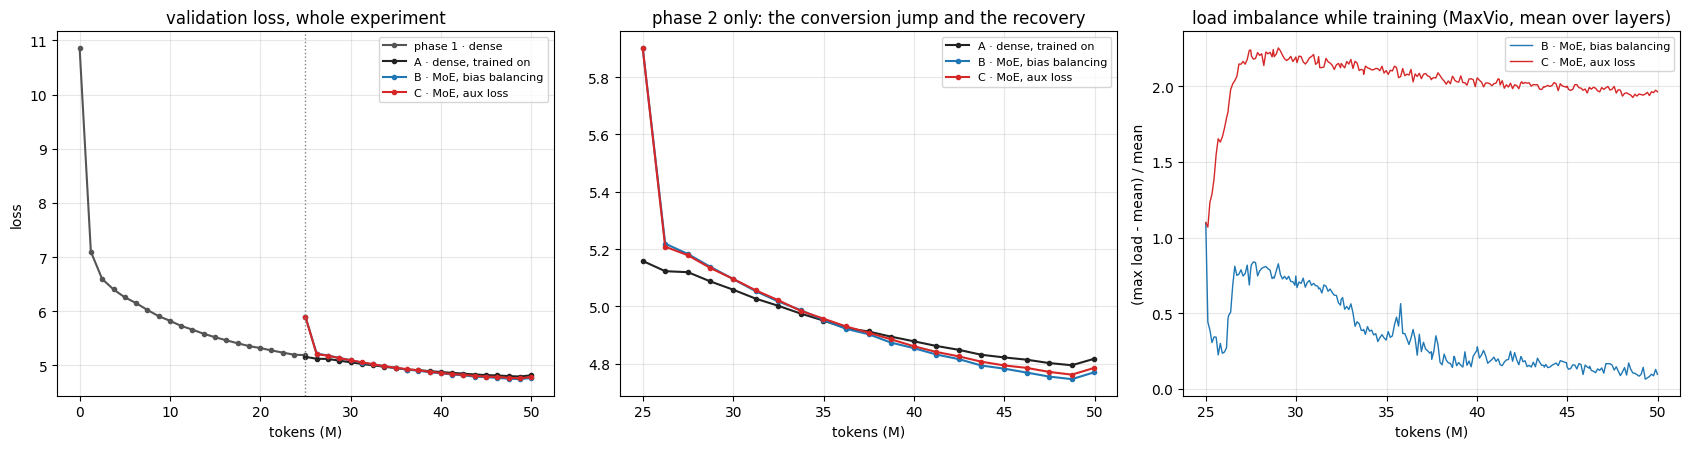

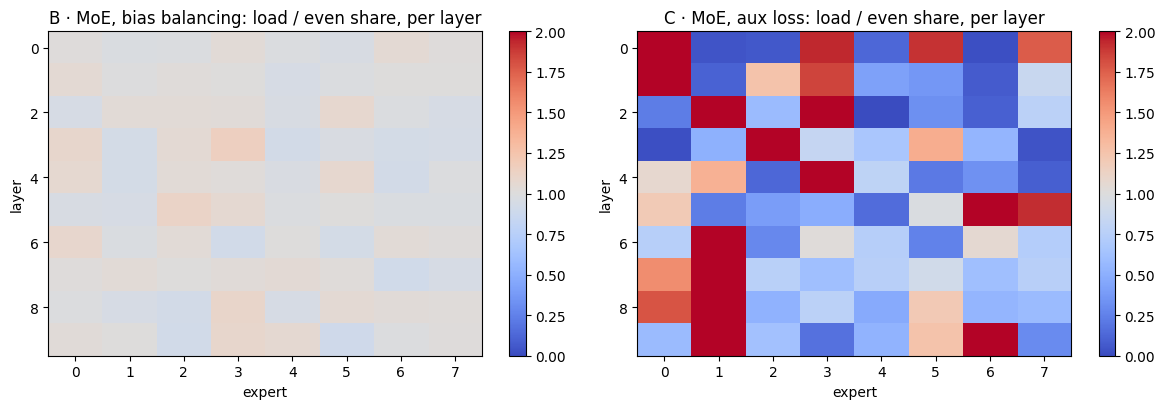

saved s14_curves.png and s14_load.png to /content/s14_runs


In [12]:
import matplotlib
if OFFLINE: matplotlib.use("Agg")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
col = {"phase 1 · dense": "#555555", "A · dense, trained on": "#222222",
       "B · MoE, bias balancing": "#1f77b4", "C · MoE, aux loss": "#d62728"}
for label, r in RUNS:
    vt = [p[0] / 1e6 for p in r["vcurve"]] + [(r["s1"] * CFG["batch"] * T) / 1e6]
    vl = [p[1] for p in r["vcurve"]] + [r["final_val"]]
    ax[0].plot(vt, vl, "o-", ms=3, color=col[label], label=label)
    if label != "phase 1 · dense":
        ax[1].plot(vt, vl, "o-", ms=3, color=col[label], label=label)
ax[0].axvline(P1["tokens"] / 1e6, color="grey", ls=":", lw=1)
ax[0].set(title="validation loss, whole experiment", xlabel="tokens (M)", ylabel="loss")
ax[1].set(title="phase 2 only: the conversion jump and the recovery", xlabel="tokens (M)")
for label, r in RUNS[2:]:
    ax[2].plot([p[0] / 1e6 for p in r["load"]], [p[1] for p in r["load"]], color=col[label], lw=1,
               label=label)
ax[2].set(title="load imbalance while training (MaxVio, mean over layers)", xlabel="tokens (M)",
          ylabel="(max load - mean) / mean")
for a_ in ax: a_.grid(alpha=0.3); a_.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(RUN_DIR, "s14_curves.png"), dpi=120)
if not OFFLINE: plt.show()
plt.close(fig)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a_, (label, r) in zip(ax, RUNS[2:]):
    cnt = np.array(r["final_counts"]); share = cnt / cnt.sum(1, keepdims=True)
    im = a_.imshow(share * CFG["experts"], aspect="auto", cmap="coolwarm", vmin=0, vmax=2)
    a_.set(title=f"{label}: load / even share, per layer", xlabel="expert", ylabel="layer")
    plt.colorbar(im, ax=a_)
plt.tight_layout(); plt.savefig(os.path.join(RUN_DIR, "s14_load.png"), dpi=120)
if not OFFLINE: plt.show()
plt.close(fig)
print("saved s14_curves.png and s14_load.png to", RUN_DIR)

## 9 · What did the experts learn?

The lesson's §9 says experts mostly specialise by **kind of token**, not by subject. That can be
checked directly. I route a validation batch through MoE-B, sort every token into a category by its
text, and ask, for one middle layer, how much of each category goes to its favourite expert. With 8
experts and top-2, the even share is 1/8 = 12.5% of the category's dispatched copies.

In [13]:
def token_kind(tid, dec):
    s = dec(tid)
    if s.strip() == "":                        return "whitespace/newline"
    if all(not ch.isalnum() for ch in s.strip()): return "punctuation"
    if s.strip().isdigit():                    return "digits"
    if s.startswith(" ") and s.strip()[:1].isupper(): return "capitalised word"
    if s.startswith(" "):                      return "lowercase word"
    return "word piece (no space)"

try:
    import tiktoken
    _enc = tiktoken.get_encoding("gpt2")
    DEC = (lambda t: _enc.decode([int(t)])) if not OFFLINE else None
except ImportError:
    DEC = None

SPEC = None
if DEC is not None:
    mB = LM(moe_cfg("bias")); mB.load_state_dict(load_state("phase2_B_moe_bias")); mB.to(DEVICE).eval()
    mid = CFG["layers"] // 2
    got = {}
    def hook(mod, inp, out):
        got["top"] = mod.route(inp[0].reshape(-1, CFG["d"]))[1].cpu()
    h_ = mB.blocks[mid].ffn.register_forward_hook(hook)
    x, y = chunk_batch(range(64), VAL)
    with torch.no_grad(), torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
        mB(x, y)
    h_.remove()
    kinds = [token_kind(t, DEC) for t in x.flatten().tolist()]
    top = got["top"]
    SPEC = {}
    for kd in sorted(set(kinds)):
        rows = torch.tensor([i for i, k_ in enumerate(kinds) if k_ == kd])
        c = torch.bincount(top[rows].flatten(), minlength=CFG["experts"]).float()
        SPEC[kd] = (len(rows), int(c.argmax()), (c.max() / c.sum()).item())
    print(f"MoE-B, layer {mid}, {x.numel():,} validation tokens; even share {100/CFG['experts']:.1f}%\n")
    print(f"{'token kind':<24}{'tokens':>8}{'favourite expert':>18}{'its share':>11}")
    for kd, (n_, e_, sh) in sorted(SPEC.items(), key=lambda kv: -kv[1][2]):
        print(f"{kd:<24}{n_:>8,}{e_:>18}{100*sh:>10.1f}%")
    del mB
else:
    print("skipped: needs the GPT-2 tokenizer (runs on Colab, not in the offline verifier)")

MoE-B, layer 5, 32,768 validation tokens; even share 12.5%

token kind                tokens  favourite expert  its share
whitespace/newline           517                 7      49.2%
digits                       537                 3      45.0%
punctuation                4,417                 7      33.8%
word piece (no space)      3,527                 3      33.4%
capitalised word           2,991                 3      30.0%
lowercase word            20,779                 6      18.9%


## 10 · Findings

Every figure below is printed from a variable measured in this run.

In [14]:
print("=" * 88)
print(f"{'FINDINGS - all measured in this run':^88}")
print("=" * 88)
print(f"dense {N_DENSE/1e6:.2f}M -> MoE {N_MOE/1e6:.2f}M total / {N_ACTIVE/1e6:.2f}M active"
      f" ({CFG['experts']} experts, top-{CFG['topk']}) | {GPU} | {AMP_DTYPE}")
print(f"data {MANIFEST['source']}: phase 1 {P1['tokens']/1e6:.1f}M tokens, phase 2 {A['tokens']/1e6:.1f}M more\n")
print(f" 1  conversion is exact with nothing redrawn: loss gap {CHECK['exact_loss_gap']:.1e}")
print(f" 2  drop-upcycling r={CFG['drop']} costs {JUMP_B:+.4f} nats at conversion"
      f" (dense {A['start_val']:.4f} -> MoE {B_['start_val']:.4f})")
print(f" 3  the MoE keeps training: B {B_['start_val']:.4f} -> {B_['final_val']:.4f},"
      f" C {C_['start_val']:.4f} -> {C_['final_val']:.4f}")
verdict = "beats" if min(GAIN_B, GAIN_C) > 0 else ("trails" if max(GAIN_B, GAIN_C) < 0 else "splits with")
print(f" 4  and {verdict} the dense model on the same tokens: dense {A['final_val']:.4f},"
      f" B {B_['final_val']:.4f} ({-GAIN_B:+.4f}), C {C_['final_val']:.4f} ({-GAIN_C:+.4f})")
if XB:
    print(f"    MoE-B overtakes dense {(XB - P1['tokens'])/1e6:.1f}M tokens after conversion")
if VB_FLOP:
    ahead = "ahead of" if VB_FLOP < A["final_val"] else "behind"
    print(f" 5  at the dense run's total compute, MoE-B is {ahead} dense: {VB_FLOP:.4f} vs {A['final_val']:.4f}")
print(f" 6  balance at the end: bias MaxVio {B_['final_load'][0]:.2f} with {B_['final_load'][1]} dead,"
      f" aux MaxVio {C_['final_load'][0]:.2f} with {C_['final_load'][1]} dead")
moved = "moved apart" if B_["final_sim"] < B_["start_sim"] else "moved closer together"
print(f" 7  experts {moved}: fc similarity {B_['start_sim']:.3f} at conversion ->"
      f" {B_['final_sim']:.3f} (B), {C_['final_sim']:.3f} (C)")
print(f" 8  cost: {100*(FLOP_MOE/FLOP_DENSE-1):+.0f}% FLOPs per token,"
      f" {100*(B_['tok_s']/A['tok_s']-1):+.0f}% measured speed, {N_MOE/N_DENSE:.2f}x the parameters")
if SPEC:
    best = max(SPEC.items(), key=lambda kv: kv[1][2])
    print(f" 9  most specialised token kind: {best[0]} -> expert {best[1][1]} takes"
          f" {100*best[1][2]:.0f}% (even {100/CFG['experts']:.1f}%)")
print("=" * 88)

                          FINDINGS - all measured in this run                           
dense 20.88M -> MoE 57.60M total / 26.15M active (8 experts, top-2) | Tesla T4 | torch.float16
data fineweb_edu_gpt2: phase 1 25.0M tokens, phase 2 25.0M more

 1  conversion is exact with nothing redrawn: loss gap 0.0e+00
 2  drop-upcycling r=0.5 costs +0.7436 nats at conversion (dense 5.1587 -> MoE 5.9023)
 3  the MoE keeps training: B 5.9023 -> 4.7701, C 5.9023 -> 4.7854
 4  and beats the dense model on the same tokens: dense 4.8172, B 4.7701 (-0.0472), C 4.7854 (-0.0319)
    MoE-B overtakes dense 11.3M tokens after conversion
 5  at the dense run's total compute, MoE-B is ahead of dense: 4.7781 vs 4.8172
 6  balance at the end: bias MaxVio 0.08 with 0 dead, aux MaxVio 1.95 with 0 dead
 7  experts moved closer together: fc similarity 0.250 at conversion -> 0.263 (B), 0.267 (C)
 8  cost: +22% FLOPs per token, -22% measured speed, 2.76x the parameters
 9  most specialised token kind: whitespace/ne